In [2]:
import originpro as op
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


file = r"H:\FUBerlin\Measurements\PLE\CristianB\20260703_ExtendedDetectorTesting\MiniVersion2.opju"
op.open(file)
for obj in op.pages():
    if type(obj).__name__ == "WBook":
        print("BOOK:", obj.name)
        for sheet in obj:
            print("   PAGE:", sheet.name)



def get_book(book_name):
    for x in op.pages():
        if type(x).__name__ == "WBook" and x.name == book_name:
            return x
    
    raise ValueError(f"Workbook '{book_name}' not found")


def plot_ple(PLE, vmin=None, vmax=None):
    plt.pcolormesh(
    PLE.columns,
    PLE.index,
    PLE.values,
    shading='auto',
    cmap='viridis',
    )
    plt.xlabel("Emission wavelength (nm)")
    plt.ylabel("Excitation wavelength (nm)")
    plt.colorbar(label="Intensity (a.u.)")
    plt.show()


BOOK: NIFilt5
   PAGE: Graph_S1c
   PAGE: Graph_S1
   PAGE: Contour_S1c
   PAGE: Contour_S1
   PAGE: Data_S1c
   PAGE: Data_S1
   PAGE: XYZ_S1c
   PAGE: XYZ_S1
   PAGE: Note
BOOK: NIFilt6
   PAGE: Graph_S1c
   PAGE: Graph_S1
   PAGE: Contour_S1c
   PAGE: Contour_S1
   PAGE: Data_S1c
   PAGE: Data_S1
   PAGE: XYZ_S1c
   PAGE: XYZ_S1
   PAGE: Note
BOOK: NIFilt7
   PAGE: Graph_S1c
   PAGE: Graph_S1
   PAGE: Contour_S1c
   PAGE: Contour_S1
   PAGE: Data_S1c
   PAGE: Data_S1
   PAGE: XYZ_S1c
   PAGE: XYZ_S1
   PAGE: Note
BOOK: NIFilt8
   PAGE: Graph_S1c
   PAGE: Graph_S1
   PAGE: Contour_S1c
   PAGE: Contour_S1
   PAGE: Data_S1c
   PAGE: Data_S1
   PAGE: XYZ_S1c
   PAGE: XYZ_S1
   PAGE: Note
BOOK: NIFilt9
   PAGE: Graph_S1c
   PAGE: Graph_S1
   PAGE: Contour_S1c
   PAGE: Contour_S1
   PAGE: Data_S1c
   PAGE: Data_S1
   PAGE: XYZ_S1c
   PAGE: XYZ_S1
   PAGE: Note
BOOK: NIFilt10
   PAGE: Graph_S1c
   PAGE: Graph_S1
   PAGE: Contour_S1c
   PAGE: Contour_S1
   PAGE: Data_S1c
   PAGE: Data_S1
  

,Int
Exc,
800.0,1.461067
807.0,1.329033
814.0,2.094633
821.0,4.479233
828.0,4.826300
835.0,3.007267
842.0,1.542367
849.0,0.787633
856.0,0.696100


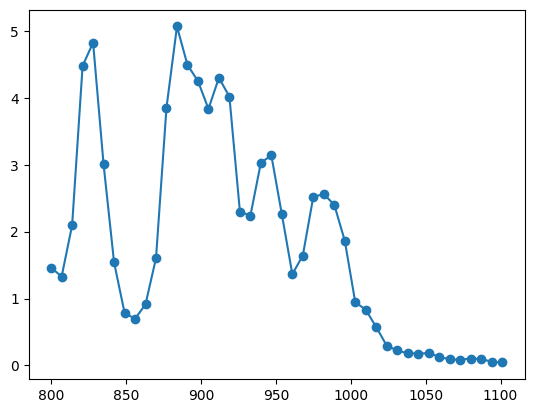

In [3]:
R1 = get_book("NIFilt4")

#for page in R1:
#    print(page.name)

pages = {page.name: page for page in R1}

Ref = pages["Data_R1"]


df = Ref.to_df().T
df = df.reset_index()
df = df[1:]
df.columns = ['Exc', 'Int']
df = df.astype(float)

plt.plot(df.Exc, df.Int)
plt.scatter(df.Exc, df.Int)

dfR1 = df
dfR1 = dfR1.set_index('Exc')
dfR1

In [4]:
NIa = get_book("NIFilt13")

for page in NIa:
    print(page.name)

pages = {page.name: page for page in NIa}

DataC = pages["Data_S1c"]
Data = pages["Data_S1"]
XYZC = pages["XYZ_S1c"]
XYZ = pages["XYZ_S1"]
Meta = pages["Note"]

df_xyz = XYZC.to_df()
df_xyz.columns = ['Em', 'Exc' ,'Int']
df_xyz = df_xyz.astype(float)




hc = 1239.84193  # eV·nm
df_xyz["Em_Energy"] = hc / df_xyz["Em"]
df_xyz["Exc_Energy"] = hc / df_xyz["Exc"]


PLE_WL = df_xyz.pivot(
    index='Exc',
    columns='Em',
    values='Int'
)


PLE_E = df_xyz.pivot(
    index='Exc_Energy',
    columns='Em_Energy',
    values='Int'
)

Graph_S1c
Graph_S1
Contour_S1c
Contour_S1
Data_S1c
Data_S1
XYZ_S1c
XYZ_S1
Note


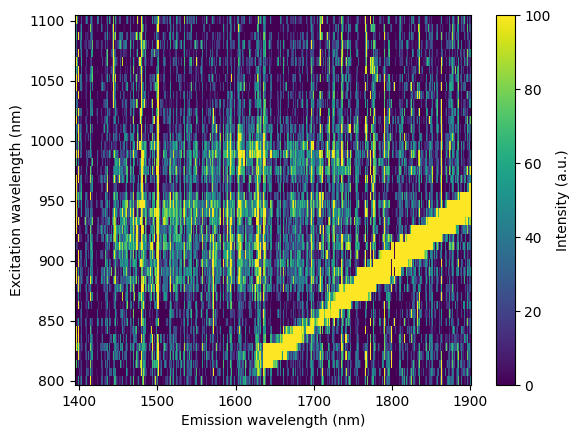

In [5]:
PLE = PLE_WL

plt.pcolormesh(
    PLE.columns,
    PLE.index,
    PLE.values,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

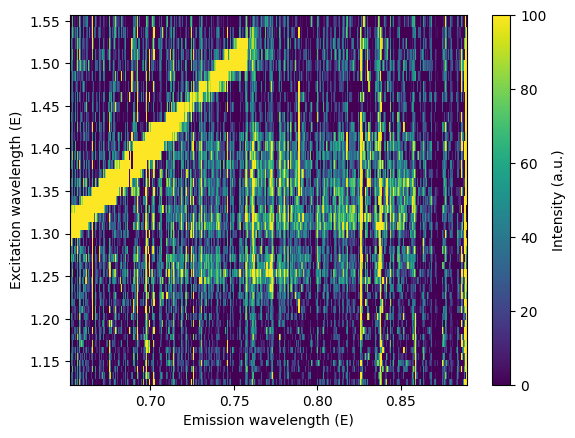

In [7]:
PLE = PLE_E

plt.pcolormesh(
    PLE.columns,
    PLE.index,
    PLE.values,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (E)")
plt.ylabel("Excitation wavelength (E)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

In [ ]:
def extract_PLE_map(book_name):
    book = get_book(book_name)

    pages = {page.name: page for page in book}

    XYZC = pages["XYZ_S1c"]

    # Origin XYZ -> pandas dataframe
    df_xyz = XYZC.to_df()

    # Rename columns
    df_xyz.columns = ['Em', 'Exc', 'Int']

    # Ensure numeric
    df_xyz = df_xyz.astype(float)

    # Add energy coordinates
    hc = 1239.84193  # eV nm

    df_xyz["Em_Energy"] = hc / df_xyz["Em"]
    df_xyz["Exc_Energy"] = hc / df_xyz["Exc"]

    # Wavelength map
    PLE_WL = df_xyz.pivot(
        index='Exc',
        columns='Em',
        values='Int'
    )

    # Energy map
    PLE_E = df_xyz.pivot(
        index='Exc_Energy',
        columns='Em_Energy',
        values='Int'
    )

    return df_xyz, PLE_WL, PLE_E

In [ ]:
sample_books = [
    "NIFilt5",
    "NIFilt6",
    "NIFilt7",
    "NIFilt8",
    "NIFilt9",
    "NIFilt10",
    "NIFilt11",
    "NIFilt12",
    "NIFilt13",
    "NIFilt14"
]

DFs = []
PLE_WLs= []
PLE_Es= []

for name in sample_books:
    df_xyz, PLE_WL, PLE_E = extract_PLE_map(name)

    DFs.append(df_xyz)
    PLE_WLs.append(PLE_WL)
    PLE_Es.append(PLE_E)



PLE_WL_sum = sum(PLE_WLs)
PLE_WL_avg = PLE_WL_sum / len(PLE_WLs)

In [ ]:
PLEMAP = PLE_WL_avg
plt.pcolormesh(
    PLEMAP.columns,
    PLEMAP.index,
    PLEMAP.values,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

PLE_WL_norm = PLE_WL_avg.div(dfR1.Int, axis=0)

PLEMAP = PLE_WL_norm
plt.pcolormesh(
    PLEMAP.columns,
    PLEMAP.index,
    PLEMAP.values,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

In [ ]:
water_books = [
    "Water3",
    "Water4",
    "Water5",
    "Water6",
    "Water7",
]

DFs_wa = []
PLE_WLs_wa= []
PLE_Es_wa= []

for name in water_books:
    df_xyz, PLE_WL, PLE_E = extract_PLE_map(name)

    DFs_wa.append(df_xyz)
    PLE_WLs_wa.append(PLE_WL)
    PLE_Es_wa.append(PLE_E)



PLE_WL_water_sum = sum(PLE_WLs_wa)
PLE_WL_water_avg = PLE_WL_water_sum / len(PLE_WLs_wa)


PLE_WL_water_sum_norm = PLE_WL_water_sum.div(dfR1.Int, axis=0)
PLE_WL_water_avg_norm = PLE_WL_water_avg.div(dfR1.Int, axis=0)


In [ ]:
PLEMAP = PLE_WL_water_sum
plt.pcolormesh(
    PLEMAP.columns,
    PLEMAP.index,
    PLEMAP.values,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

PLEMAP = PLE_WL_water_avg
plt.pcolormesh(
    PLEMAP.columns,
    PLEMAP.index,
    PLEMAP.values,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

In [ ]:
PLE_WL_water_avg

In [ ]:
PLEMAP = PLE_WL_water_avg
plt.pcolormesh(
    PLEMAP.columns,
    PLEMAP.index,
    PLEMAP.values,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

In [ ]:
PLEMAP = PLE_WL_avg
plt.pcolormesh(
    PLEMAP.columns,
    PLEMAP.index,
    PLEMAP.values,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

In [ ]:
PLEMAP = PLE_WL_avg-PLE_WL_water_avg

In [ ]:
PLEMAP = PLEMAP
plt.pcolormesh(
    PLEMAP.columns,
    PLEMAP.index,
    PLEMAP.values,
    shading='auto',
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

In [ ]:
import h5py
import numpy as np

filename = "PLE_dataset.h5"

with h5py.File(filename, "w") as f:

    ple_group = f.create_group("PLE_WL")

    # Create wavelength axes
    excitation = ple_group.create_dataset(
        "excitation_nm",
        data=PLE_WL_avg.index.values
    )

    emission = ple_group.create_dataset(
        "emission_nm",
        data=PLE_WL_avg.columns.values
    )

    # Create intensity matrix
    intensity = ple_group.create_dataset(
        "intensity",
        data=PLE_WL_avg.values
    )

    # Mark wavelength datasets as dimension scales
    excitation.make_scale("Excitation wavelength (nm)")
    emission.make_scale("Emission wavelength (nm)")

    # Attach scales to intensity dimensions
    intensity.dims[0].attach_scale(excitation)
    intensity.dims[1].attach_scale(emission)

    # Optional labels
    intensity.dims[0].label = "Excitation (nm)"
    intensity.dims[1].label = "Emission (nm)"


    # XYZ data
    xyz_group = f.create_group("XYZ")

    xyz_group.create_dataset(
        "Em_nm",
        data=df_xyz["Em"].values
    )

    xyz_group.create_dataset(
        "Exc_nm",
        data=df_xyz["Exc"].values
    )

    xyz_group.create_dataset(
        "Intensity",
        data=df_xyz["Int"].values
    )

print("Saved:", filename)
   

In [ ]:
import h5py
import matplotlib.pyplot as plt

filename = "PLE_dataset.h5"

with h5py.File(filename, "r") as f:
    excitation = f["PLE_WL"]["excitation_nm"][:]
    emission = f["PLE_WL"]["emission_nm"][:]
    intensity = f["PLE_WL"]["intensity"][:]

# Plot PLE map with correct physical axes
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    emission,          # X axis: emission wavelength
    excitation,        # Y axis: excitation wavelength
    intensity,
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")

plt.tight_layout()
plt.show()